In [1]:
import cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Paths
RAW = Path('../data/raw')
PROC = Path('../data/processed')
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']

print("OpenCV version:", cv2.__version__)
print("Raw data exists:", RAW.exists())

OpenCV version: 4.13.0
Raw data exists: True


In [2]:
def crop_brain(img_gray):
    """
    Crop the image to a tight bounding box around the brain region.
    Works by thresholding (anything brighter than near-black is considered brain),
    finding the largest connected region, and returning its bounding box.
    """
    # Threshold: pixels brighter than 10 are 'brain', else background
    _, thresh = cv2.threshold(img_gray, 10, 255, cv2.THRESH_BINARY)
    
    # Clean up: dilate then erode to remove small holes/specks
    thresh = cv2.dilate(thresh, None, iterations=2)
    thresh = cv2.erode(thresh, None, iterations=2)
    
    # Find contours (connected regions)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_gray  # fallback: return original if nothing found
    
    # Largest contour = the brain
    biggest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(biggest)
    
    # Add a small padding so we don't clip the brain edge
    pad = 5
    h_img, w_img = img_gray.shape
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w_img, x + w + pad)
    y2 = min(h_img, y + h + pad)
    
    return img_gray[y1:y2, x1:x2]

# Quick test on one image
test_path = next((RAW / 'Training' / 'glioma').glob('*'))
test_img = cv2.imread(str(test_path), cv2.IMREAD_GRAYSCALE)
test_cropped = crop_brain(test_img)

print(f"Original shape: {test_img.shape}")
print(f"Cropped shape: {test_cropped.shape}")

Original shape: (512, 512)
Cropped shape: (481, 403)


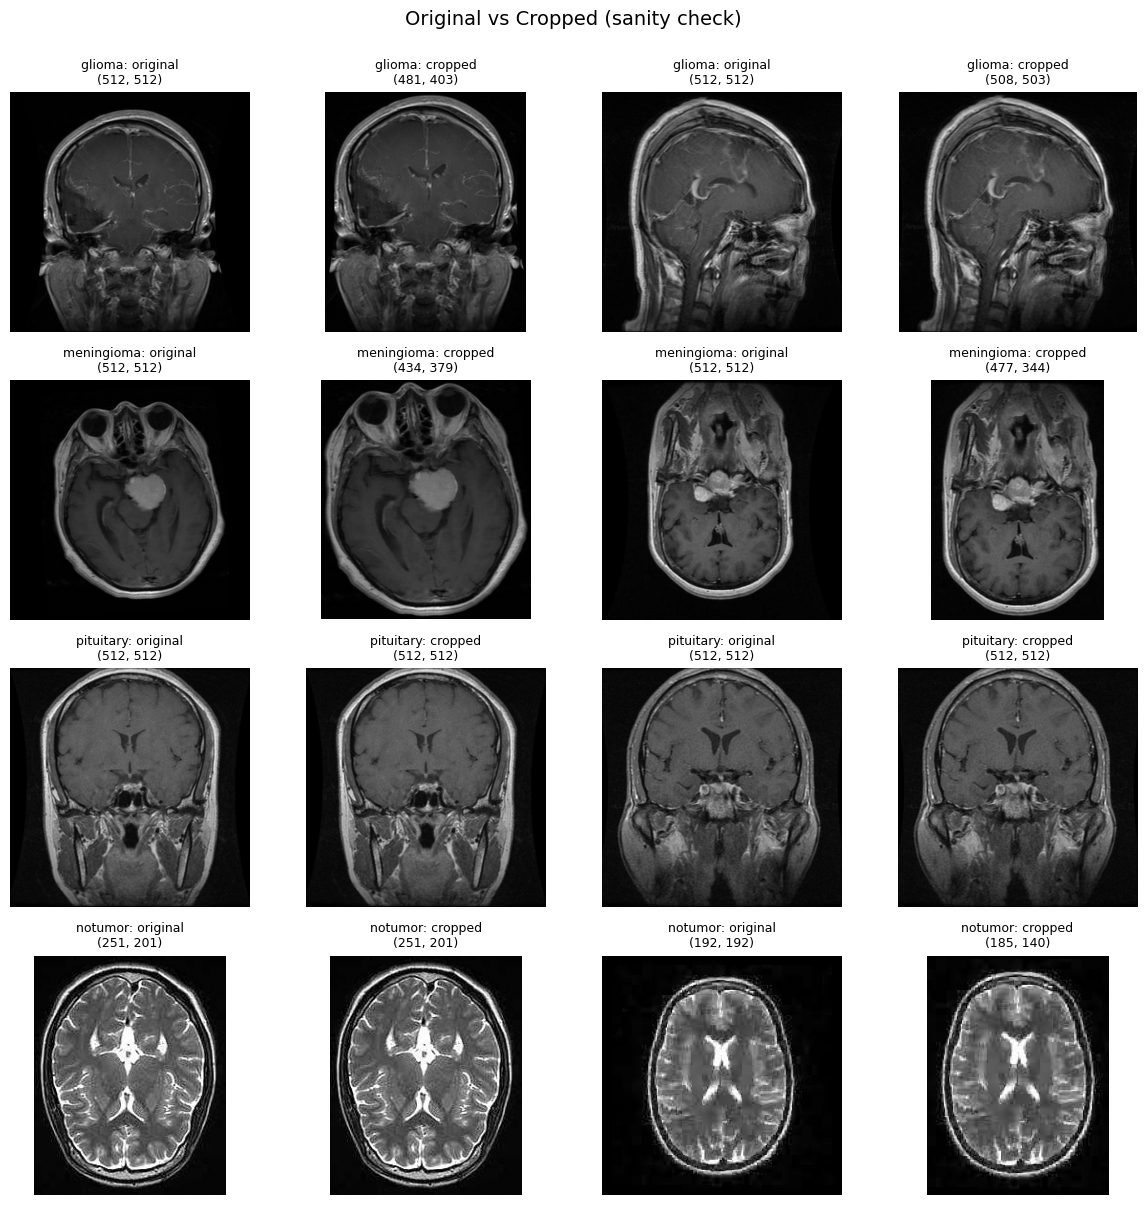

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, c in enumerate(CLASSES):
    files = list((RAW / 'Training' / c).glob('*'))[:2]  # take first 2 of each class
    for i, f in enumerate(files):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        cropped = crop_brain(img)
        
        axes[row, i*2].imshow(img, cmap='gray')
        axes[row, i*2].set_title(f"{c}: original\n{img.shape}", fontsize=9)
        axes[row, i*2].axis('off')
        
        axes[row, i*2+1].imshow(cropped, cmap='gray')
        axes[row, i*2+1].set_title(f"{c}: cropped\n{cropped.shape}", fontsize=9)
        axes[row, i*2+1].axis('off')

plt.suptitle("Original vs Cropped (sanity check)", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('../outputs/crop_qa.png', dpi=120, bbox_inches='tight')
plt.show()

Test write success: True
Output exists: True


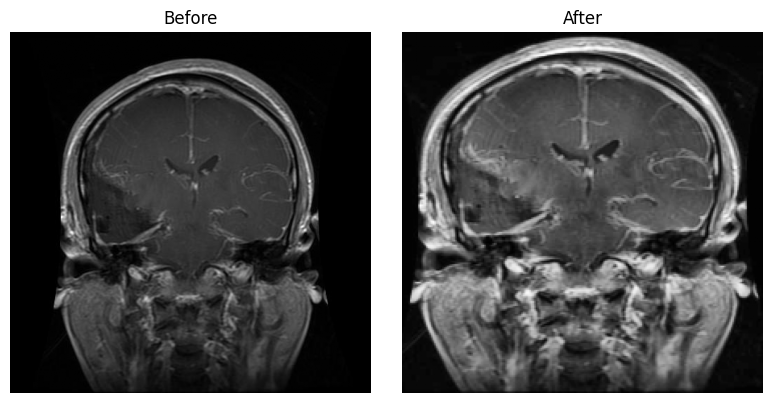

In [4]:
def preprocess_one(in_path, out_path, size=224):
    """
    Full preprocessing for one image:
    1. Read as grayscale
    2. Crop to brain region
    3. Resize to size x size
    4. Apply CLAHE contrast enhancement
    5. Save as PNG
    """
    img = cv2.imread(str(in_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False  # skip if read failed
    
    img = crop_brain(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    
    # CLAHE: adaptive contrast enhancement, helps reveal subtle texture
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    
    # Make sure output folder exists, then save
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), img)
    return True

# Test on one image to confirm the function works end-to-end
test_in = next((RAW / 'Training' / 'glioma').glob('*'))
test_out = PROC / 'Training' / 'glioma' / 'TEST_OUTPUT.png'
ok = preprocess_one(test_in, test_out)
print(f"Test write success: {ok}")
print(f"Output exists: {test_out.exists()}")

# Show before/after
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(cv2.imread(str(test_in), cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[0].set_title("Before"); axes[0].axis('off')
axes[1].imshow(cv2.imread(str(test_out), cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[1].set_title("After"); axes[1].axis('off')
plt.tight_layout(); plt.show()

# Clean up the test file
test_out.unlink()

In [5]:
print("Starting preprocessing of all images...")
print("This will take 5-15 minutes. Don't close anything.")
print()

success_count = 0
fail_count = 0

for split in ['Training', 'Testing']:
    for c in CLASSES:
        in_dir = RAW / split / c
        files = list(in_dir.glob('*'))
        
        for f in tqdm(files, desc=f'{split}/{c}'):
            out_path = PROC / split / c / f'{f.stem}.png'
            if preprocess_one(f, out_path):
                success_count += 1
            else:
                fail_count += 1

print(f"\nDone!")
print(f"Successfully processed: {success_count} images")
print(f"Failed: {fail_count} images")

Starting preprocessing of all images...
This will take 5-15 minutes. Don't close anything.



Training/glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/pituitary:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/notumor:   0%|          | 0/1400 [00:00<?, ?it/s]

Testing/glioma:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/meningioma:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/pituitary:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/notumor:   0%|          | 0/400 [00:00<?, ?it/s]


Done!
Successfully processed: 7200 images
Failed: 0 images


Split      Class           Count     
----------------------------------------
Training   glioma          1400      
Training   meningioma      1400      
Training   pituitary       1400      
Training   notumor         1400      
Testing    glioma          400       
Testing    meningioma      400       
Testing    pituitary       400       
Testing    notumor         400       


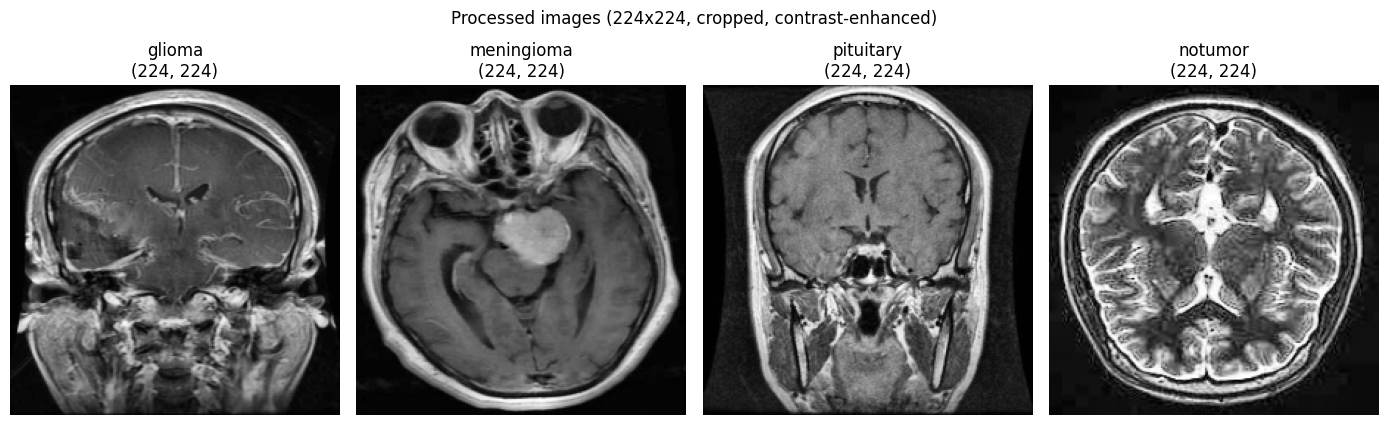

In [8]:
# Count what got saved
print(f"{'Split':<10} {'Class':<15} {'Count':<10}")
print("-" * 40)
for split in ['Training', 'Testing']:
    for c in CLASSES:
        n = len(list((PROC / split / c).glob('*.png')))
        print(f"{split:<10} {c:<15} {n:<10}")

# Show a sample to confirm they look right
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, c in enumerate(CLASSES):
    sample = next((PROC / 'Training' / c).glob('*.png'))
    img = cv2.imread(str(sample), cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{c}\n{img.shape}")
    axes[i].axis('off')

plt.suptitle("Processed images (224x224, cropped, contrast-enhanced)", fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig('../outputs/preprocess_qa.png', dpi=120, bbox_inches='tight')
plt.show()